# Indiana Pines

1. Import dependencies

In [1]:
import random
import torch
import multiprocessing
import time
import numpy as np

import torch.utils.data as data

from src.util.torch import resolve_torch_device
from src.util.hsi import (
    extract_patches,
    reduce_hsi_dim,
    preprocess_hsi,
    PreProcessType,
    DimReductionType,
)
from src.data.indian_pines import load_indian_pines
from src.visualization.plot import (
    plot_epoch_generic,
)

from src.util.reporting import (
    create_model_name,
    report_run,
    read_report_to_show,
)
from src.util.list_ext import smooth_moving_average
from src.util.scheduler import CosineLRSchedulerWrapper
from src.model.dbda import DBDA
from src.trainer.masked_autoencoder_trainer import (
    HsiPatchMasking,
    MaskedAutoEncoderTrainer,
)
from src.util.loss import MaskedAutoencoderLoss
from src.util.torch import save_model
from src.trainer.base_trainer import AdamOptimizedModule
from src.model.autoencoder import AutoEncoder
from src.model.vit_hsi_decoder import ViTHsiDecoder

2. Prepare env

In [2]:
run_desk = "MAE transformer run"

In [3]:
learning_rate = 1e-3
weight_decay = 0
num_epochs = 40

In [4]:
loss_alpha = 1
loss_beta = 0.1

mask_ratio = 0.5
mask_mode = "both"
fil_value = "noise"

latent_space_size = 256

In [5]:
batch_size = 64
patch_size = 9
target_dim = 75

examples_per_class = {}

pre_process_type = PreProcessType.STANDARTIZATION
dim_reduction_type = DimReductionType.PCA

In [6]:
random_seed = 42

random.seed(random_seed)
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = resolve_torch_device()

In [7]:
epoch_seconds = int(time.time())

In [8]:
torch.cuda.empty_cache()

In [9]:
torch.set_float32_matmul_precision("medium")

In [10]:
f"Device is {device}"

'Device is cuda'

3. Load dataset

In [11]:
image, labels = load_indian_pines()

image_h, image_w, image_c = image.shape

In [12]:
_, image = preprocess_hsi(image, pre_process_type)

In [13]:
_, target_dim, image = reduce_hsi_dim(
    image, target_dim, dim_reduction_type, device, random_seed
)

In [14]:
x, y = extract_patches(image, labels, patch_size=patch_size)

In [15]:
num_classes = len(np.unique(y))

f"Number of classes {num_classes}"

'Number of classes 17'

In [16]:
x_tensor = torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2) 
y_tensor = torch.tensor(y, dtype=torch.long)

In [17]:
cpu_count = multiprocessing.cpu_count()

f"Setting num_workers to {cpu_count}"

'Setting num_workers to 24'

In [18]:
full_dataset = data.TensorDataset(x_tensor, y_tensor)

full_loader = data.DataLoader(
    full_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=cpu_count,
    persistent_workers=True,
)

4. Train model

In [19]:
encoder = DBDA(
    band=target_dim,
    classes=latent_space_size,
)

In [20]:
decoder = ViTHsiDecoder(out_h=9, out_w=9, out_bands=target_dim)

In [ ]:
model = AdamOptimizedModule(
    net=AutoEncoder(encoder, decoder),
    lr=learning_rate,
    weight_decay=weight_decay,
    scheduler=lambda optimizer: CosineLRSchedulerWrapper(
        optimizer,
        t_initial=num_epochs,
        lr_min=learning_rate * 0.01,
        warmup_t=int(np.ceil(0.1 * num_epochs)),
        warmup_lr_init=learning_rate * 0.01,
    ),
)

In [ ]:
trainer = MaskedAutoEncoderTrainer(
    loss_fun=MaskedAutoencoderLoss(alpha=loss_alpha, beta=loss_beta),
    epochs=num_epochs,
    masking=HsiPatchMasking(
        mask_ratio=mask_ratio, mode=mask_mode, fill_value=fil_value
    ),
    device=device,
)

In [25]:
feedback = trainer.fit(model, full_loader)

  0%|          | 0/40 [00:00<?, ?it/s]

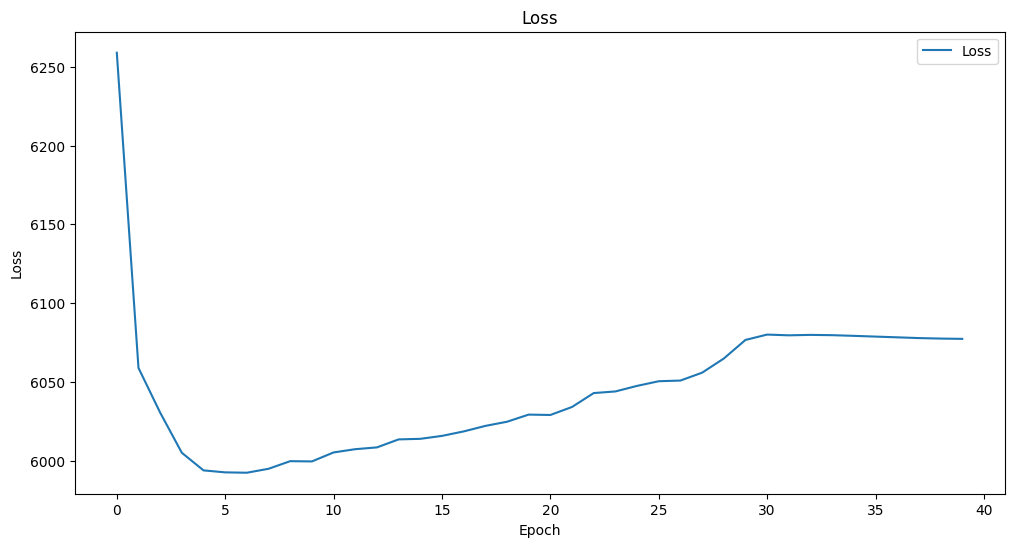

In [26]:
smothed_train = smooth_moving_average([it.train["train_loss"] for it in feedback.history], 1)

plot_epoch_generic(smothed_train, desc="Loss")

In [27]:
validation_result = trainer.validate(model, full_loader)

validation_result

ValueError: not enough values to unpack (expected 4, got 2)

5. Save weights

In [ ]:
saved_model_name = f"indian_pines_mae_encoder_{run_desk.replace(" ", "_").lower()}"

save_model(encoder, saved_model_name)

6. Write report

In [ ]:
model_name = create_model_name("indian_pines_mae", {})

model_category = "dbda"

In [ ]:
run_params = {
    "num_epochs": num_epochs,
    "batch_size": batch_size,
    "patch_size": patch_size,
    "target_dim": target_dim,
    "loss_alpha": loss_alpha,
    "loss_beta": loss_beta,
    "mask_ratio": mask_ratio,
    "mask_mode": mask_mode,
    "fil_value": fil_value,
    "embedding_size": latent_space_size,
    "pre_process_type": str(pre_process_type),
    "dim_reduction_type": str(dim_reduction_type),
    "saved_model_name": saved_model_name,
}

report_run(
    model_name=model_name,
    model_category=model_category,
    run_desc=run_desk,
    run_params=run_params | model.get_params(),
    run_metrics={"loss": validation_result["eval_loss"]},
)

In [ ]:
read_report_to_show(model_name, sort_by_metric="loss", ascending=True)

In [ ]:
read_report_to_show(
    model_name, sort_by_metric="loss", model_category=model_category, ascending=True
)